# Machine Learning Models

## Baseline Linear Regression

Objective

Train a baseline regression model for Remaining Useful Life prediction.

## Load libraries and dataset

Load the prepared dataset

In [26]:
import pandas as pd
df = pd.read_csv('../data/processed/train_FD001_features.csv')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 91 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   unit_number                        20631 non-null  int64  
 1   time_in_cycles                     20631 non-null  int64  
 2   operational_setting_1              20631 non-null  float64
 3   operational_setting_2              20631 non-null  float64
 4   operational_setting_3              20631 non-null  float64
 5   sensor_measurement_1               20631 non-null  float64
 6   sensor_measurement_2               20631 non-null  float64
 7   sensor_measurement_3               20631 non-null  float64
 8   sensor_measurement_4               20631 non-null  float64
 9   sensor_measurement_5               20631 non-null  float64
 10  sensor_measurement_6               20631 non-null  float64
 11  sensor_measurement_7               20631 non-null  float64
 12  s

In [27]:
import os
os.makedirs("../reports/figures", exist_ok=True)

# Recreate X and y

The target is RUL, everything else other than identifiers like `unit_number` becomes our features.

## Split the data

In [28]:
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

# 0. Drop warm up rows and leaky columns
df_model = df[df['time_in_cycles'] >= 5].reset_index(drop=True)

groups = df_model['unit_number']
x = df_model.drop(columns=['RUL', 'max_cycles', 'unit_number'])
y = df_model['RUL']

# 1. Split by engine; 80 engines train, 20 engines test
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(x, y, groups=groups))

x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# 2. Scale fit on train only
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(x_train.shape, x_test.shape)
print("train engines:", groups.iloc[train_idx].nunique(),
      "test engines:", groups.iloc[test_idx].nunique())
print("overlap:", set(groups.iloc[train_idx]) & set(groups.iloc[test_idx]))


(16241, 88) (3990, 88)
train engines: 80 test engines: 20
overlap: set()


## Import linear regression

Initialize and fit the model

In [29]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](88,)","[ -0.35,-137.94,3797.63,..., 0. , -5.11, -8.88]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](88,)","['time_in_cycles','operational_setting_1','operational_setting_2',..., 'sensor_measurement_19_change','sensor_measurement_20_change', 'sensor_measurement_21_change']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.084e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,88
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(63)


## Predict values for unseen test data

In [30]:
y_pred = model.predict(x_test)

## Evaluate model

Using three metrics:
- Mean absolute error
- Root mean squared error
- R² Score

In [31]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

mae  = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f} cycles")
print(f"RMSE: {rmse:.2f} cycles")
print(f"R²:   {r2:.3f}")

MAE:  24.90 cycles
RMSE: 31.39 cycles
R²:   0.764


# Plot actual vs predictions

Compare the predicted values to the actual values using scatter plots.

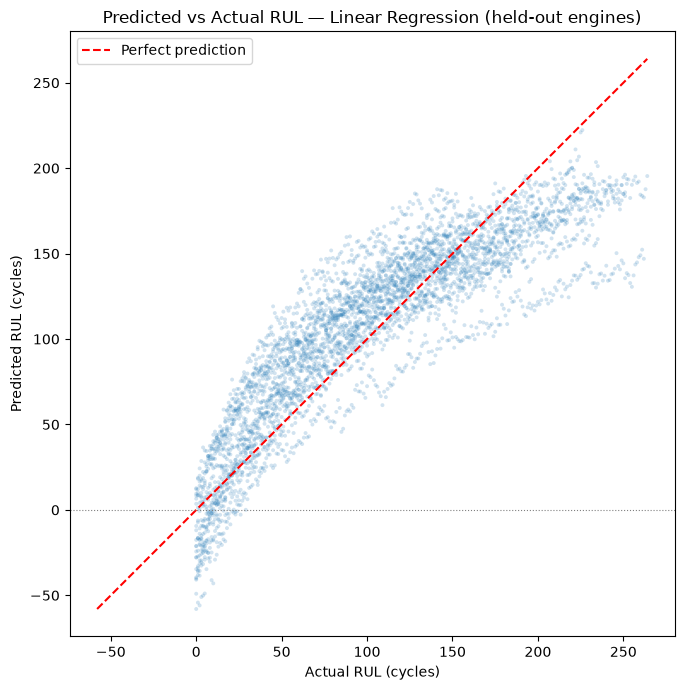

In [32]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(y_test, y_pred, alpha=0.2, s=8, edgecolor='none')

# Perfect prediction reference line
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')

ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')

ax.set_xlabel('Actual RUL (cycles)')
ax.set_ylabel('Predicted RUL (cycles)')
ax.set_title('Predicted vs Actual RUL — Linear Regression (held-out engines)')
ax.set_aspect('equal')
ax.legend()

# Save the plot
plt.tight_layout()

plt.savefig("../reports/figures/prediction_scatter.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Observations

- Points below the red line = the model predicts less life than the engine actually had.
- Points above the line = the model predicts more life than there was. These are the dangerous ones: the engine fails sooner than you were told.
- Predictions below zero. Linear regression is unbounded, so it will output negative RUL.
- A flattened, tilted cloud. The model will over predict at low actual RUL and under predict at high actual RUL.


# Residual plot

Residual = actual - predicted.

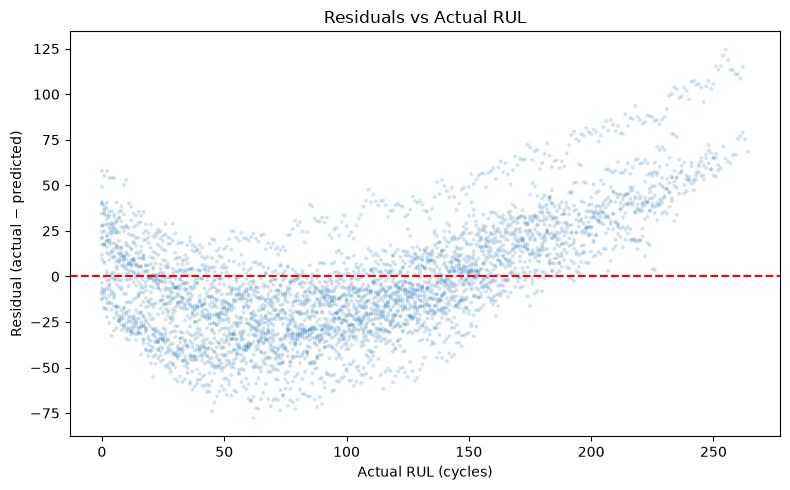

In [33]:
residuals = y_test - y_pred

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_test, residuals, alpha=0.2, s=8, edgecolor='none')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Actual RUL (cycles)')
ax.set_ylabel('Residual (actual − predicted)')
ax.set_title('Residuals vs Actual RUL')

# Save the plot
plt.tight_layout()

plt.savefig("../reports/figures/residual_plot.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Save the model

Later, the dashboard will load this file directly.

In [34]:
import joblib
joblib.dump(model, 'linear_regression_model.pkl')

['linear_regression_model.pkl']

# Decision tree regression

The relationship between wear & tear vs health is often non linear. Decision trees can capture these non linear relationships.

In [38]:
from sklearn.tree import DecisionTreeRegressor
decision_tree = DecisionTreeRegressor()
decision_tree.fit(x_train, y_train)

,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_node

# Predictions

In [40]:
decision_tree_pred = decision_tree.predict(x_test)

# Evaluate model

In [41]:
mae  = mean_absolute_error(y_test, decision_tree_pred)
rmse = root_mean_squared_error(y_test, decision_tree_pred)
r2   = r2_score(y_test, decision_tree_pred)

print(f"MAE:  {mae:.2f} cycles")
print(f"RMSE: {rmse:.2f} cycles")
print(f"R²:   {r2:.3f}")

MAE:  33.73 cycles
RMSE: 47.02 cycles
R²:   0.470
